# Block 4: Deep-Learning and Feature Extraction

Now that we have worked through the basic image processing techniques, we will dive into the limitations that can be noticed using those techniques on real world data. We will then take a look at how newer techniques such as machine learning methods can help us where data is a bit trickier to process.

After using state-of-the-art models, we will look into what features we can extract from our images, and how we can represent them using Python.

## Thresholding On Real-World Data

As seen in Block 3, thresholding methods work very well on datasets and images that are evenly lit, and where the contrast between background and foreground is clear. Unfortunately, this is not always the case with real-world microscopy images. We encounter cases where some nuclei are missing signal and where some cells are very faint on a daily basis. Let's take a look at an example.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, io, morphology, measure
import pandas as pd
import tifffile
from scipy.ndimage import uniform_filter
from ipywidgets import interact, widgets
import stackview
from skimage import exposure
from skimage.measure import regionprops_table

from cellpose import models
from cellpose.io import imread
import napari


Image shape: (3, 1011, 1557)


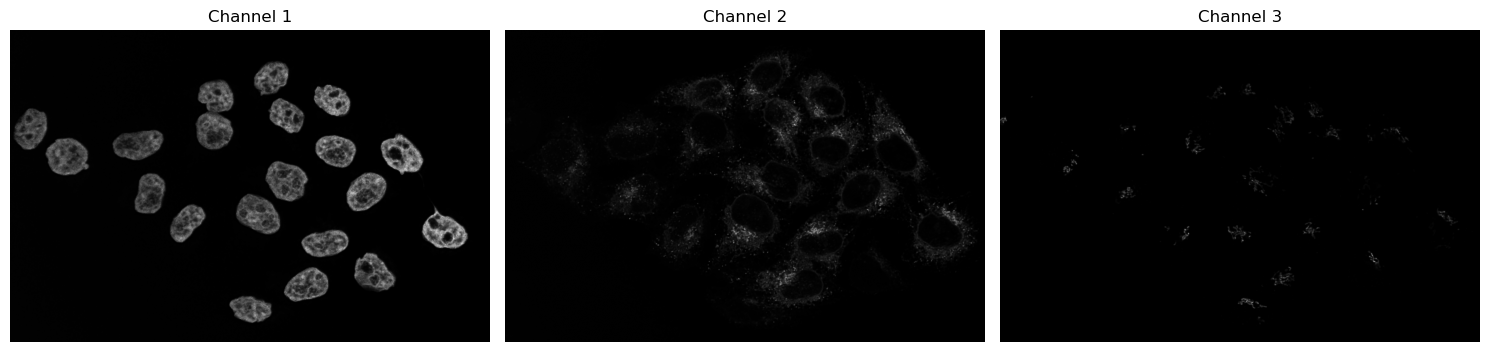

In [2]:
raw_img = "../data_block4/rab9a-egfp-slice-cropped.tif"
# We can use cellpose's imread function to read the image
img = imread(raw_img)

# With img.shape, we can check the dims of the image and number of channels
print(f"Image shape: {img.shape}")

# As this is a 3-channel image, we can visualize each channel separately
fig, ax = plt.subplots(1, 3, figsize=(15, 15))

ax[0].imshow(img[0], cmap="gray")
ax[0].set_title("Channel 1")
ax[0].axis("off")

ax[1].imshow(img[1], cmap="gray")
ax[1].set_title("Channel 2")
ax[1].axis("off")

ax[2].imshow(img[2], cmap="gray")
ax[2].set_title("Channel 3")
ax[2].axis("off")

plt.tight_layout()
plt.show()


Let's analyse the nuclei first in Channel 1. As discussed before, we start with a threshold to then make objects.

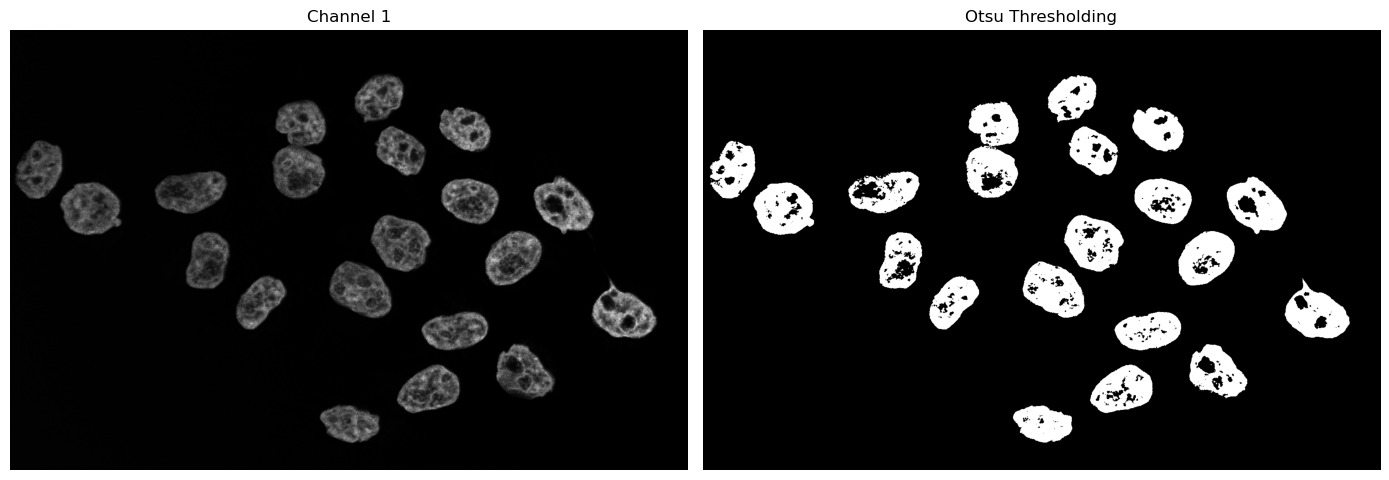

In [3]:
img_ch1 = img[0]
img_ch2 = img[1]
# Let's use Otsu's method on channel 1
img_ch1_otsu_t = filters.threshold_otsu(img_ch1)

# Keep only those that are above the threshold
binary_ch1 = img_ch1 > img_ch1_otsu_t
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

# Plotting code
ax[0].imshow(img_ch1, cmap="gray")
ax[0].set_title("Channel 1")
ax[0].axis("off")

ax[1].imshow(binary_ch1, cmap="gray")
ax[1].set_title("Otsu Thresholding")
ax[1].axis("off")
plt.tight_layout()
plt.show()

As we can see, the binary image has some "holes" in the nuclei due to dim or even no signal being captured inside the nucleus. There are multiple ways we could go about fixing this. **Morphological operations** are simple image-processing techniques that change the shape of objects in a binary image by adding or removing pixels based on their neighbors. These operations can help clean up segmentation results by filling holes or removing small artifacts.

Operations such as closing can fill small gaps inside objects, while opening operations can remove small signals of noise. These methods work only on a binary image and can be used quickly to improve thresholding and binarization results.

However, these operations rely on intact neighborhoods - if large parts of the object is missing from the threshold, a closing operation cannot fix large missing segmentations.

An alternative approach is the use of **deep-learning models**. Trained models have the capability to recognize even dim signals, and can take into account shape information, and not just signal strength. Such models can produce much better results in cases such as the one above with holes and semi-recognized objects. In the following, we use **Cellpose**, a deep-learning framework specifically trained to segment nuclei and cells in microscopy.

### Running Cellpose on Nuclei

[Cellpose] is a generalist algorithm for segmenting cells and nuclei. There are 2 main versions of cellpose in use right now: **cellpose-3** and **cellpose-SAM**. The version we will present in the next sections is the older **cellpose-3** versions, where the model needs a diameter parameter in pixels, so that it knows what size of objects it is trying to segment. For this, we will have to use an image processing software like napari to estimate the size. The next cell launches an interactive window in napari, where you can choose 2 points across the nucleus. Then, run the next cell - your line will be measured and automatically fed into the model.

[Cellpose]: https://www.biorxiv.org/content/10.1101/2020.02.02.931238v1

In [4]:
%gui qt
import napari
import numpy as np

viewer = napari.Viewer()
viewer.add_image(img_ch1, name="channel1")

# Add an empty shapes layer ready for line drawing
shapes_layer = viewer.add_shapes(
    name="measure", face_color="transparent", edge_color="red"
)
shapes_layer.mode = "add_line"

print("Draw a line across one nucleus, then run the next cell.")

Draw a line across one nucleus, then run the next cell.


In [6]:
# Read the first line you drew: shape is [[y0, x0], [y1, x1]]
line = shapes_layer.data[0]
measured_diameter = np.linalg.norm(line[1] - line[0])
# measured_diameter = 170
print(f"Measured diameter: {measured_diameter:.1f} px")

print("Now running Cellpose on the nuclei with the measured diameter...")
model = models.Cellpose(gpu=True, model_type="nuclei")
masks_c1, flows_c1, styles_c1, diams_c1 = model.eval(
    img_ch1, diameter=measured_diameter, channels=[0, 0]
)

Measured diameter: 164.5 px
Now running Cellpose on the nuclei with the measured diameter...


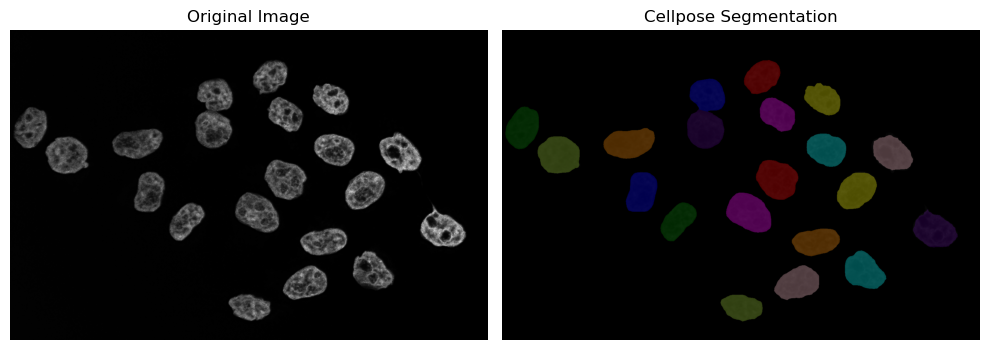

In [8]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result
from skimage.color import label2rgb

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_ch1, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# plt.imshow(img_ch1, cmap="gray")
labels_rgb_c1 = label2rgb(
    label=masks_c1,
    image=img_ch1,
    bg_label=0,  # Needed to tell the function that 0 is background and should not be colored
)
plt.imshow(labels_rgb_c1)
plt.title("Cellpose Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

### Running Cellpose on cytoplasm

In [9]:
print("Now running Cellpose on the cytoplasm with a fixed diameter...")
model = models.Cellpose(gpu=True, model_type="cyto3")
masks_c2, flows_c2, styles_c2, diams_c2 = model.eval(
    img_ch2, diameter=200, channels=[0, 0]
)

Now running Cellpose on the cytoplasm with a fixed diameter...


100%|██████████| 25.3M/25.3M [00:01<00:00, 13.9MB/s]
100%|██████████| 3.54k/3.54k [00:00<00:00, 3.09MB/s]


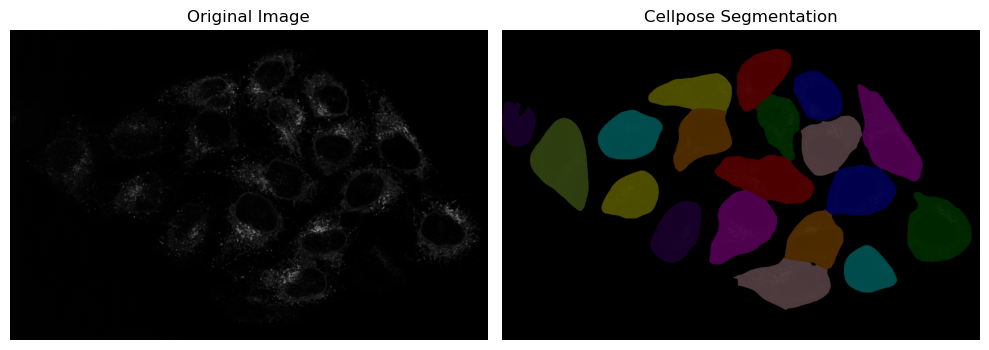

In [10]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result
from skimage.color import label2rgb

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_ch2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# plt.imshow(img_ch1, cmap="gray")
labels_rgb_c2 = label2rgb(
    label=masks_c2,
    image=img_ch2,
    bg_label=0,  # Needed to tell the function that 0 is background and should not be colored
)
plt.imshow(labels_rgb_c2)
plt.title("Cellpose Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

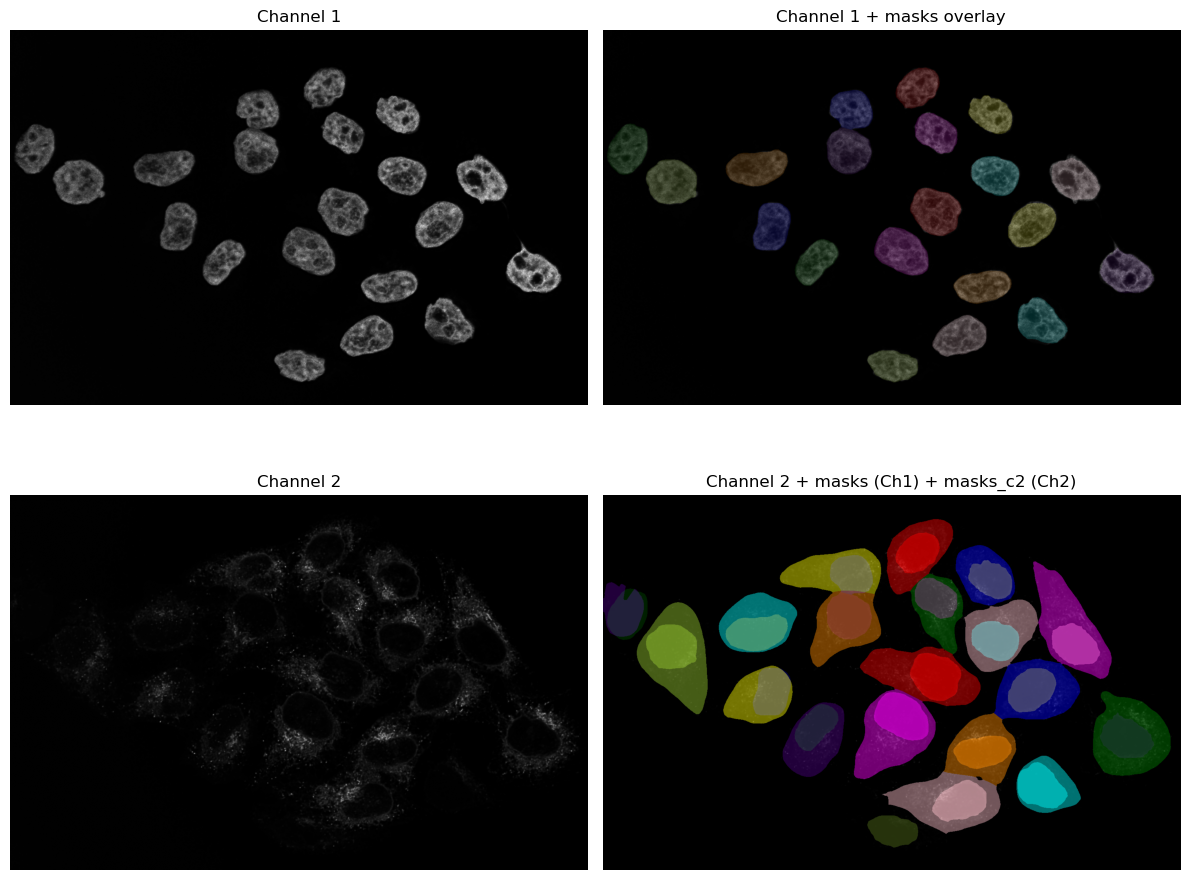

In [11]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result in a 2x2 grid:
# [0,0] img_ch1, [0,1] img_ch1 + masks overlay
# [1,0] img_ch2, [1,1] img_ch2 + masks + masks_c2 overlay
from skimage.color import label2rgb
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: Channel 1 original
axes[0, 0].imshow(img_ch1, cmap="gray")
axes[0, 0].set_title("Channel 1")
axes[0, 0].axis("off")

# Top-right: Channel 1 with masks overlay
labels_rgb_ch1 = label2rgb(label=masks_c1, image=img_ch1, bg_label=0)
axes[0, 1].imshow(img_ch1, cmap="gray")
axes[0, 1].imshow(labels_rgb_ch1, alpha=0.5)
axes[0, 1].set_title("Channel 1 + masks overlay")
axes[0, 1].axis("off")

# Bottom-left: Channel 2 original
axes[1, 0].imshow(img_ch2, cmap="gray")
axes[1, 0].set_title("Channel 2")
axes[1, 0].axis("off")

# Bottom-right: Channel 2 with masks (from ch1) and masks_c2 overlayed
# Create colored mask images for each label image
labels_rgb_masks = label2rgb(label=masks_c1, bg_label=0)
labels_rgb_masks_c2 = label2rgb(label=masks_c2, bg_label=0)
axes[1, 1].imshow(img_ch2, cmap="gray")
axes[1, 1].imshow(labels_rgb_masks, alpha=0.45)
axes[1, 1].imshow(labels_rgb_masks_c2, alpha=0.45)
axes[1, 1].set_title("Channel 2 + masks (Ch1) + masks_c2 (Ch2)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### Running cellpose on cytoplasm using nuclei as seeds

In [12]:
# Read the first line you drew: shape is [[y0, x0], [y1, x1]]
print("Now running Cellpose on the cytoplasm with a fixed diameter...")
model = models.Cellpose(gpu=True, model_type="cyto3")
masks_c2c1, flows_c2c1, styles_c2c1, diams_c2c1 = model.eval(
    img_ch2, diameter=200, channels=[1, 0]
)

Now running Cellpose on the cytoplasm with a fixed diameter...


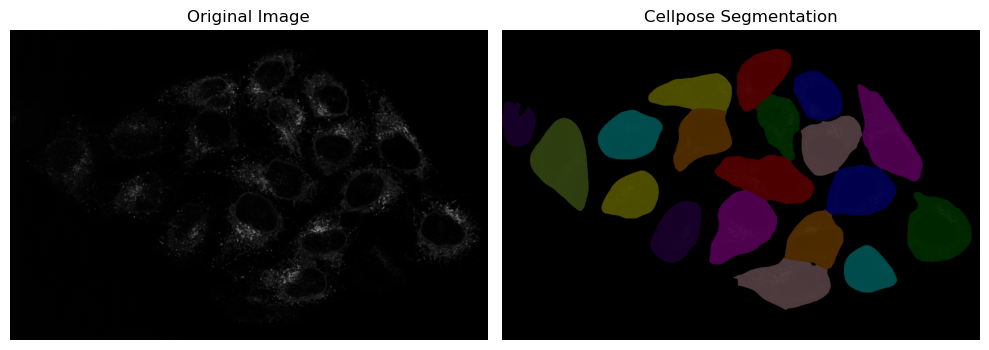

In [13]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result
from skimage.color import label2rgb

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_ch2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# plt.imshow(img_ch1, cmap="gray")
labels_rgb_c2c1 = label2rgb(
    label=masks_c2c1,
    image=img_ch2,
    bg_label=0,  # Needed to tell the function that 0 is background and should not be colored
)
plt.imshow(labels_rgb_c2)
plt.title("Cellpose Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

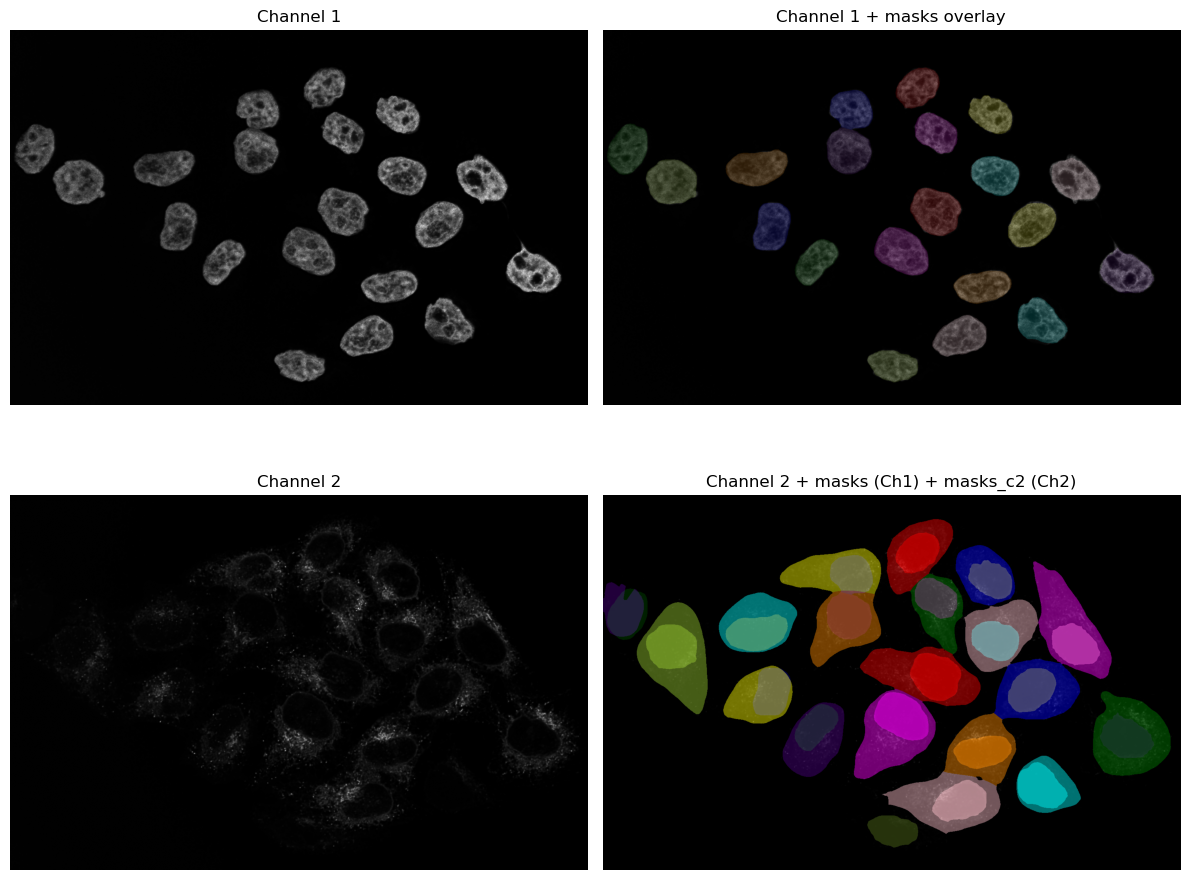

In [14]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result in a 2x2 grid:
# [0,0] img_ch1, [0,1] img_ch1 + masks overlay
# [1,0] img_ch2, [1,1] img_ch2 + masks + masks_c2 overlay
from skimage.color import label2rgb
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: Channel 1 original
axes[0, 0].imshow(img_ch1, cmap="gray")
axes[0, 0].set_title("Channel 1")
axes[0, 0].axis("off")

# Top-right: Channel 1 with masks overlay
labels_rgb_ch1 = label2rgb(label=masks_c1, image=img_ch1, bg_label=0)
axes[0, 1].imshow(img_ch1, cmap="gray")
axes[0, 1].imshow(labels_rgb_ch1, alpha=0.5)
axes[0, 1].set_title("Channel 1 + masks overlay")
axes[0, 1].axis("off")

# Bottom-left: Channel 2 original
axes[1, 0].imshow(img_ch2, cmap="gray")
axes[1, 0].set_title("Channel 2")
axes[1, 0].axis("off")

# Bottom-right: Channel 2 with masks (from ch1) and masks_c2 overlayed
# Create colored mask images for each label image
labels_rgb_masks = label2rgb(label=masks_c1, bg_label=0)
labels_rgb_masks_c2c1 = label2rgb(label=masks_c2c1, bg_label=0)
axes[1, 1].imshow(img_ch2, cmap="gray")
axes[1, 1].imshow(labels_rgb_masks, alpha=0.45)
axes[1, 1].imshow(labels_rgb_masks_c2c1, alpha=0.45)
axes[1, 1].set_title("Channel 2 + masks (Ch1) + masks_c2 (Ch2)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Compute properties for cells (masks) and nuclei (masks_c2), then match by overlap
from skimage.measure import regionprops
import numpy as np

cells = regionprops(masks_c1, intensity_image=img_ch1)
nucs = regionprops(masks_c2c1, intensity_image=img_ch2)
# Build lookup for nucleus properties by label
nuc_lookup = {}
for n in nucs:
    nuc_lookup[n.label] = {
        "nuclei_label": int(n.label),
        "nuclei_area": float(n.area),
        "nuclei_centroid_row": float(n.centroid[0]),
        "nuclei_centroid_col": float(n.centroid[1]),
        "nuclei_intensity_mean_ch2": float(getattr(n, "intensity_mean", np.nan)),
    }
# For each cell, find the overlapping nucleus (most overlapping label) and combine properties
rows = []
for c in cells:
    cell_label = int(c.label)
    mask_idx = masks_c1 == cell_label
    overlap = masks_c2c1[mask_idx]
    # find most common non-zero overlapping nucleus label
    labels, counts = np.unique(overlap, return_counts=True)
    matched_n = 0
    if labels.size > 0:
        # remove background label 0 if present
        nz = labels != 0
        if nz.any():
            labels_nz = labels[nz]
            counts_nz = counts[nz]
            matched_n = int(labels_nz[np.argmax(counts_nz)])
    cell_row = {
        "cell_label": cell_label,
        "cell_area": float(c.area),
        "cell_centroid_row": float(c.centroid[0]),
        "cell_centroid_col": float(c.centroid[1]),
        "cell_perimeter": float(getattr(c, "perimeter", np.nan)),
        "cell_intensity_mean_ch1": float(getattr(c, "intensity_mean", np.nan)),
        "cell_feret_diameter_max": float(getattr(c, "feret_diameter_max", np.nan)),
        "matched_nucleus_label": matched_n,
    }
    # attach nucleus info if matched
    if matched_n and matched_n in nuc_lookup:
        cell_row.update(nuc_lookup[matched_n])
    else:
        cell_row.update(
            {
                "nuclei_label": np.nan,
                "nuclei_area": np.nan,
                "nuclei_centroid_row": np.nan,
                "nuclei_centroid_col": np.nan,
                "nuclei_intensity_mean_ch2": np.nan,
            }
        )
    rows.append(cell_row)
# Create DataFrame and round numeric columns to 2 decimals
df_matched = pd.DataFrame(rows).round(2)
display(df_matched)

,cell_label,cell_area,cell_centroid_row,cell_centroid_col,cell_perimeter,cell_intensity_mean_ch1,cell_feret_diameter_max,matched_nucleus_label,nuclei_label,nuclei_area,nuclei_centroid_row,nuclei_centroid_col,nuclei_intensity_mean_ch2
0,1,9523.0,155.06,847.58,375.16,1868.55,128.41,1,1.0,23639.0,155.81,844.80,478.27
1,2,9693.0,214.08,670.13,378.08,1862.46,124.17,3,3.0,24062.0,207.35,628.52,462.66
2,3,8883.0,227.59,1045.21,373.26,2492.47,130.43,2,2.0,19107.0,216.69,1029.00,548.74
3,4,9242.0,277.31,896.95,373.26,1951.72,129.63,5,5.0,19664.0,306.36,903.62,712.75
4,5,11148.0,320.95,66.91,403.55,1545.89,141.66,6,6.0,12038.0,310.51,51.25,118.27
5,6,11931.0,326.45,661.07,415.16,1646.46,132.28,7,7.0,25949.0,348.79,649.59,282.08
6,7,12547.0,370.92,414.47,453.16,1424.66,171.29,8,8.0,25295.0,346.15,415.43,237.76
7,8,10733.0,391.56,1057.16,393.26,2100.28,133.33,9,9.0,27477.0,373.93,1067.15,450.53
8,9,10669.0,403.99,1270.98,406.33,2593.90,144.22,4,4.0,34583.0,354.56,1255.67,459.30
9,10,13293.0,409.39,185.27,437.50,1783.49,146.82,10,10.0,37612.0,432.11,199.14,255.03


## Feature Extraction

Once we have segmented our objects, we can extract features from them. 
As the result from Cellpose is a label image (an image where each object has a
unique label), we can use this image to extract various features for each
segmented object. Common features include:
- **Area**: The number of pixels that belong to the object.
- **Perimeter**: The length of the boundary of the object.
- **Centroid**: The center of mass of the object.
- **Mean Intensity**: The average intensity of the pixels that belong to the object.
- **Ferret Diameter**: The diameter of a circle with the same area as the object.

This can be done using the `regionprops_table` function from `skimage.measure`. This function takes the raw image and a labeled image and returns a list of properties for each object.

In [16]:
props_nuclei = regionprops_table(
    label_image=masks_c1,
    intensity_image=img_ch1,
    properties=[
        "area",
        "perimeter",
        "centroid",
        "intensity_mean",
        "feret_diameter_max",
    ],
)
# Convert to DataFrame, rename intensity column to indicate channel, and round
df_props_nuclei = (
    pd.DataFrame(props_nuclei)
    .rename(columns={"intensity_mean": "intensity_mean_ch1"})
    .round(2)
)
display(df_props_nuclei)

,area,perimeter,centroid-0,centroid-1,intensity_mean_ch1,feret_diameter_max
0,9523.0,375.16,155.06,847.58,1868.55,128.41
1,9693.0,378.08,214.08,670.13,1862.46,124.17
2,8883.0,373.26,227.59,1045.21,2492.47,130.43
3,9242.0,373.26,277.31,896.95,1951.72,129.63
4,11148.0,403.55,320.95,66.91,1545.89,141.66
5,11931.0,415.16,326.45,661.07,1646.46,132.28
6,12547.0,453.16,370.92,414.47,1424.66,171.29
7,10733.0,393.26,391.56,1057.16,2100.28,133.33
8,10669.0,406.33,403.99,1270.98,2593.90,144.22
9,13293.0,437.50,409.39,185.27,1783.49,146.82


In [17]:
props_cells = regionprops_table(
    label_image=masks_c2c1,
    intensity_image=img_ch2,
    properties=[
        "area",
        "perimeter",
        "centroid",
        "intensity_mean",
        "feret_diameter_max",
    ],
)
# Convert to DataFrame, rename intensity column to indicate channel, and round
df_props_c2 = (
    pd.DataFrame(props_cells)
    .rename(columns={"intensity_mean": "intensity_mean_ch2"})
    .round(2)
)
display(df_props_c2)

,area,perimeter,centroid-0,centroid-1,intensity_mean_ch2,feret_diameter_max
0,23639.0,627.17,155.81,844.80,478.27,238.81
1,19107.0,533.63,216.69,1029.00,548.74,186.64
2,24062.0,700.17,207.35,628.52,462.66,275.23
3,34583.0,883.03,354.56,1255.67,459.30,367.72
4,19664.0,602.20,306.36,903.62,712.75,227.11
5,12038.0,508.96,310.51,51.25,118.27,153.94
6,25949.0,685.09,348.79,649.59,282.08,250.50
7,25295.0,613.71,346.15,415.43,237.76,218.00
8,27477.0,665.37,373.93,1067.15,450.53,225.79
9,37612.0,798.65,432.11,199.14,255.03,308.30


As you can see, the DataFrame contains the extracted features for each nucleus. We can do the same for the cells segmented in Channel 2. We can also match the nuclei and cells together to see which nucleus belongs to which cell, and extract features from both together.

In [18]:
# Display cell/object label 20 from masks_c2 (crop + overlay) and show properties
label = 20
mask20 = masks_c2 == label
if mask20.sum() == 0:
    print(f"Label {label} not present in masks_c2")
else:
    from skimage.measure import regionprops
    import numpy as np

    props = regionprops(mask20.astype(int), intensity_image=img_ch2)
    if len(props) > 0:
        p = props[0]
        print(
            f"Label {label}: area={p.area:.2f}, centroid=({p.centroid[0]:.2f}, {p.centroid[1]:.2f}), mean_intensity={getattr(p, 'mean_intensity', np.nan):.2f}"
        )
        bbox = p.bbox  # (min_row, min_col, max_row, max_col)
        minr, minc, maxr, maxc = bbox
        pad = 10
        minr = max(0, minr - pad)
        minc = max(0, minc - pad)
        maxr = min(img_ch2.shape[0], maxr + pad)
        maxc = min(img_ch2.shape[1], maxc + pad)
        crop_img = img_ch2[minr:maxr, minc:maxc]
        crop_mask = mask20[minr:maxr, minc:maxc]
        import matplotlib.pyplot as plt

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(crop_img, cmap="gray")
        plt.title(f"Cell {label} (crop)")
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(crop_img, cmap="gray")
        plt.imshow(crop_mask, cmap="Reds", alpha=0.6)
        plt.title("Overlay mask")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No region properties found for this mask (empty region)")
    # Check matched table if available
    if "df_matched" in globals():
        row = df_matched[df_matched["cell_label"] == label]
        if not row.empty:
            print("Matched nucleus label:", row.iloc[0].get("matched_nucleus_label"))
        else:
            print("No entry for this cell in matched table (no matched nucleus)")

Label 20 not present in masks_c2


Found 1 cells with no matched nucleus


,cell_label,cell_area,cell_centroid_row,cell_centroid_col
19,20,8802.0,904.46,781.41


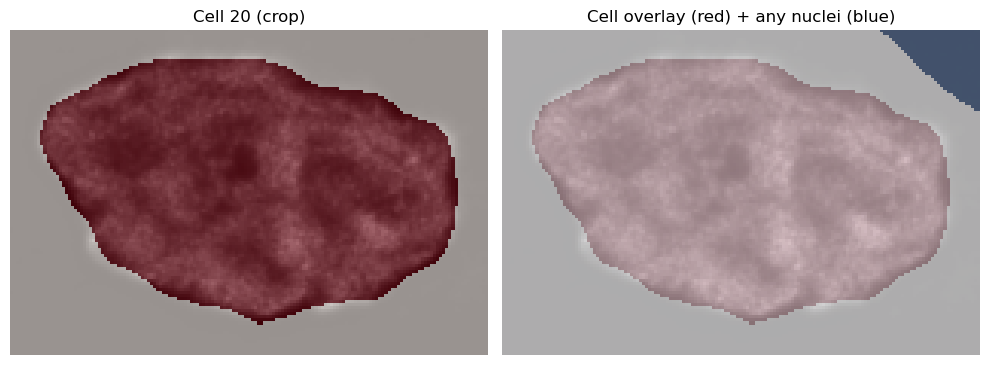

In [20]:
# Identify cells that have no matched nucleus and visualize a few examples
if "df_matched" not in globals():
    print("Please run the matching cell first to produce `df_matched`.")
else:
    import matplotlib.pyplot as plt
    import numpy as np

    # unmatched where matched_nucleus_label is NaN or 0
    unmatched = df_matched[
        df_matched["matched_nucleus_label"].isna()
        | (df_matched["matched_nucleus_label"] == 0)
    ]
    print(f"Found {len(unmatched)} cells with no matched nucleus")
    if len(unmatched) == 0:
        display(df_matched.head())
    else:
        display(
            unmatched[
                ["cell_label", "cell_area", "cell_centroid_row", "cell_centroid_col"]
            ].head(50)
        )
        # Visualize up to 6 unmatched cells
        n_show = min(6, len(unmatched))
        labels_to_show = unmatched["cell_label"].astype(int).tolist()[:n_show]
        fig, axes = plt.subplots(n_show, 2, figsize=(10, 4 * n_show))
        if n_show == 1:
            axes = np.array([axes])
        for i, lab in enumerate(labels_to_show):
            lab = int(lab)
            mask_cell = masks_c1 == lab
            props = regionprops(mask_cell.astype(int), intensity_image=img_ch1)
            if len(props) > 0:
                p = props[0]
                minr, minc, maxr, maxc = p.bbox
                pad = 10
                minr = max(0, minr - pad)
                minc = max(0, minc - pad)
                maxr = min(img_ch1.shape[0], maxr + pad)
                maxc = min(img_ch1.shape[1], maxc + pad)
                crop_img = img_ch1[minr:maxr, minc:maxc]
                crop_mask_cell = mask_cell[minr:maxr, minc:maxc]
                crop_mask_nuc = masks_c2[minr:maxr, minc:maxc] > 0
            else:
                # fallback to whole image if regionprops fails
                crop_img = img_ch1
                crop_mask_cell = mask_cell
                crop_mask_nuc = masks_c2 > 0
            ax1 = axes[i, 0]
            ax2 = axes[i, 1]
            ax1.imshow(crop_img, cmap="gray")
            ax1.imshow(crop_mask_cell, cmap="Reds", alpha=0.6)
            ax1.set_title(f"Cell {lab} (crop)")
            ax1.axis("off")
            ax2.imshow(crop_img, cmap="gray")
            ax2.imshow(crop_mask_cell, cmap="Reds", alpha=0.45)
            ax2.imshow(crop_mask_nuc, cmap="Blues", alpha=0.45)
            ax2.set_title("Cell overlay (red) + any nuclei (blue)")
            ax2.axis("off")
        plt.tight_layout()
        plt.show()

## Output depends on the biological question

Then, once you have managed to get this far, you can start asking yourself what features are relevant to your biological question. Do you care about the size of the nucleus? The intensity of the signal in the cytoplasm? The shape of the cell? The possibilities are endless, and it really depends on your specific question and what you are trying to understand from your data.

### Distribution of area of nuclei and cells

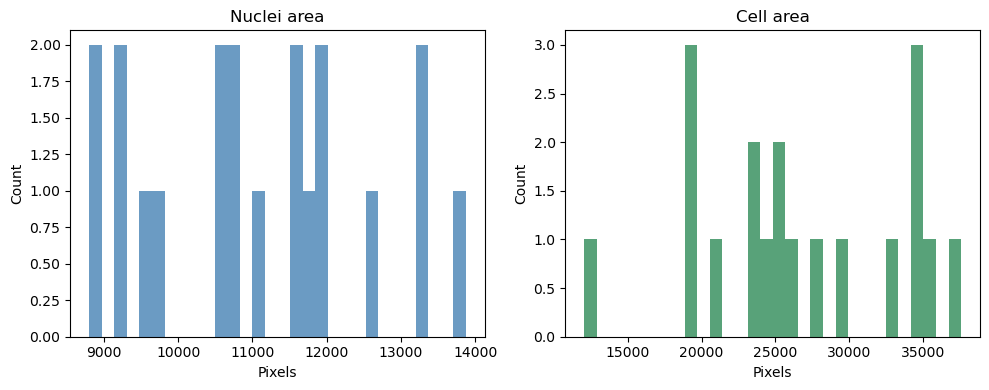

Nuclei: n=20, mean area=11043.5 px
Cells:  n=19, mean area=26615.8 px


In [ ]:
# Choose available labels
nuc_labels = masks_c1
if "masks_c2c1" in globals():
    cell_labels = masks_c2c1
elif "masks_c2" in globals():
    cell_labels = masks_c2
else:
    raise RuntimeError("No cell labels found (masks_c2 or masks_c2c1)")

# Collect areas
nuc_areas = [p.area for p in regionprops(nuc_labels)]
cell_areas = [p.area for p in regionprops(cell_labels)]

# Plotting code
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(nuc_areas, bins=30, color="steelblue", alpha=0.8)
ax[0].set_title("Nuclei area")
ax[0].set_xlabel("Pixels")
ax[0].set_ylabel("Count")

ax[1].hist(cell_areas, bins=30, color="seagreen", alpha=0.8)
ax[1].set_title("Cell area")
ax[1].set_xlabel("Pixels")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Nuclei: n={len(nuc_areas)}, mean area={sum(nuc_areas)/len(nuc_areas):.1f} px")
print(f"Cells:  n={len(cell_areas)}, mean area={sum(cell_areas)/len(cell_areas):.1f} px")

### Distribution of intensity of nuclei and cells



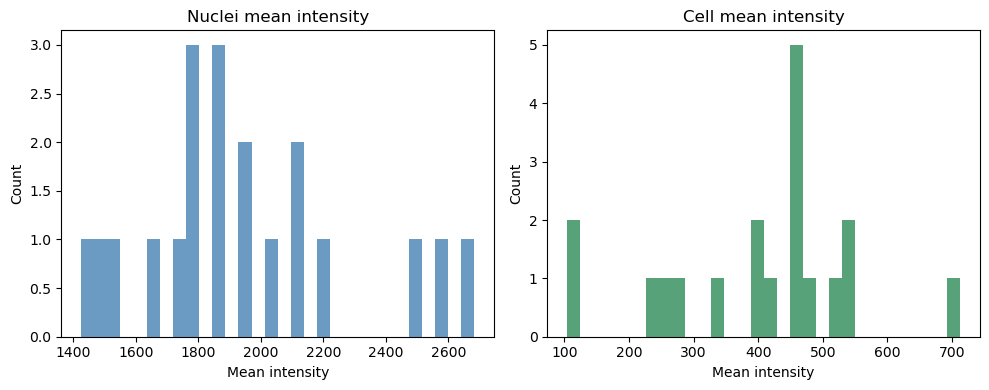

Nuclei: n=20, mean=1947.40
Cells:  n=19, mean=401.35


In [23]:
# Choose available labels
nuc_labels = masks_c1
if "masks_c2c1" in globals():
    cell_labels = masks_c2c1
elif "masks_c2" in globals():
    cell_labels = masks_c2
else:
    raise RuntimeError("No cell labels found (masks_c2 or masks_c2c1)")

# Collect mean intensities
nuc_means = [p.intensity_mean for p in regionprops(nuc_labels, intensity_image=img_ch1)]
cell_means = [p.intensity_mean for p in regionprops(cell_labels, intensity_image=img_ch2)]

# Simple, compact plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(nuc_means, bins=30, color="steelblue", alpha=0.8)
ax[0].set_title("Nuclei mean intensity")
ax[0].set_xlabel("Mean intensity")
ax[0].set_ylabel("Count")

ax[1].hist(cell_means, bins=30, color="seagreen", alpha=0.8)
ax[1].set_title("Cell mean intensity")
ax[1].set_xlabel("Mean intensity")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Nuclei: n={len(nuc_means)}, mean={sum(nuc_means)/len(nuc_means):.2f}")
print(f"Cells:  n={len(cell_means)}, mean={sum(cell_means)/len(cell_means):.2f}")

### Ratio of nuclear to cytoplasmic area

             median   mean  count
method                           
guided_cyto   0.661  0.865     19
raw_cyto      0.661  0.865     19


/tmp/ipykernel_829561/366543368.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showfliers=False)


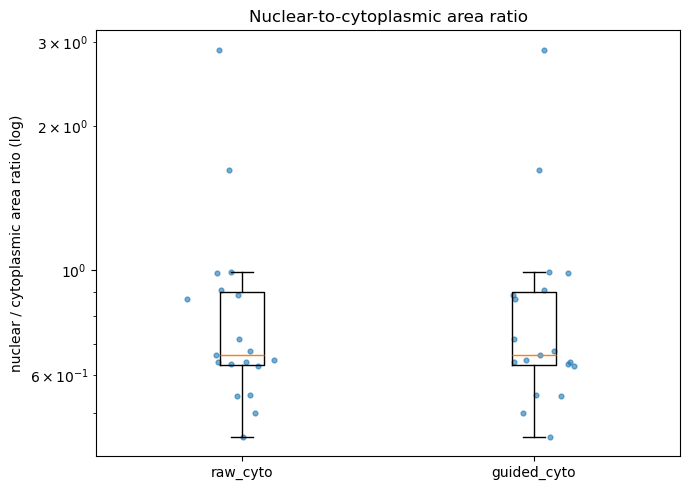

,median,mean,count
method,,,
guided_cyto,0.661,0.865,19
raw_cyto,0.661,0.865,19


In [21]:
# Calculate and plot nuclear-to-cytoplasmic area ratios for masks_c1 vs masks_c2c1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import regionprops

nuc_labels = masks_c1 if "masks_c1" in globals() else masks
cyto_variants = {}
if "masks_c2" in globals():
    cyto_variants["raw_cyto"] = masks_c2
if "masks_c2c1" in globals():
    cyto_variants["guided_cyto"] = masks_c2c1

if not cyto_variants:
    raise RuntimeError("No cytoplasm segmentation found (masks_c2 or masks_c2c1)")

# helper for mode
from collections import defaultdict


def compute_mode(vals, bins=256):
    vals = np.asarray(vals)
    if vals.size == 0:
        return np.nan
    if np.issubdtype(vals.dtype, np.integer):
        try:
            counts = np.bincount(vals - vals.min())
            return float(np.argmax(counts) + vals.min())
        except Exception:
            pass
    hist, edges = np.histogram(vals, bins=bins)
    idx = np.argmax(hist)
    return float(0.5 * (edges[idx] + edges[idx + 1]))


rows = []
for name, cyto in cyto_variants.items():
    for prop in regionprops(cyto):
        cl = int(prop.label)
        cell_area = int(prop.area)
        mask_cell = cyto == cl
        nuc_pixels = int((nuc_labels[mask_cell] > 0).sum())
        cyt_area = cell_area - nuc_pixels
        ratio = np.nan if cyt_area <= 0 else nuc_pixels / float(cyt_area)
        rows.append({"method": name, "cell_label": cl, "ratio": ratio})

df_plot = pd.DataFrame(rows).dropna(subset=["ratio"])

summary = df_plot.groupby("method")["ratio"].agg(["median", "mean", "count"]).round(3)
print(summary)

fig, ax = plt.subplots(figsize=(7, 5))
methods = df_plot["method"].unique()
data = [df_plot.loc[df_plot["method"] == m, "ratio"].values for m in methods]
ax.boxplot(data, labels=methods, showfliers=False)
for i, m in enumerate(methods):
    y = df_plot.loc[df_plot["method"] == m, "ratio"].values
    x = np.random.normal(i + 1, 0.06, size=len(y))
    ax.scatter(x, y, alpha=0.6, s=12, color="C0")
ax.set_yscale("log")
ax.set_ylabel("nuclear / cytoplasmic area ratio (log)")
ax.set_title("Nuclear-to-cytoplasmic area ratio")
plt.tight_layout()
plt.show()

display(summary)